# Práctica 1: Riesgo

Analizamos el riesgo de **cinco ETF de gestión activa** con diez años de retornos diarios: tres de acciones
y dos de renta fija.

| ETF | Ticker | Qué hace | Cotiza desde |
| --- | --- | --- | --- |
| Cambria Shareholder Yield | `SYLD` | Acciones de EE. UU. que más caja devuelven al accionista: dividendos, recompras y reducción de deuda | may-2013 |
| Alpha Architect International Quantitative Value | `IVAL` | *Value* profundo internacional, cartera concentrada de 50-100 valores | dic-2014 |
| ARK Innovation | `ARKK` | Crecimiento disruptivo | oct-2014 |
| State Street DoubleLine Total Return Tactical | `TOTL` | Renta fija flexible gestionada por DoubleLine | feb-2015 |
| First Trust Preferred Securities and Income | `FPE` | Preferentes e híbridos, con gestión fundamental | feb-2013 |

**Convenciones.** Retornos simples diarios en decimal (0,01 = 1 %). Las pérdidas (drawdown, VaR, CVaR) se
expresan **en positivo**. VaR y CVaR son diarios y al 95 %. Tipo libre de riesgo igual a cero. Los precios
están ajustados por dividendos y distribuciones.

Antes de abrirlo, ejecuta `uv sync --locked` en la raíz del repositorio y elige como kernel el entorno `.venv`
del proyecto.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from statistics import NormalDist

from quantmgmt import risk
from quantmgmt.data import download_prices

TICKERS = ["SYLD", "IVAL", "ARKK", "TOTL", "FPE"]
COLORS = {
    "SYLD": "#1d3557",
    "IVAL": "#f4a261",
    "ARKK": "#7b2cbf",
    "TOTL": "#2a9d8f",
    "FPE": "#e63946",
}
CONFIDENCE = 0.95

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "legend.frameon": False,
})
PCT = mtick.PercentFormatter(1.0, decimals=0)

## 1. Datos

Descargamos con yfinance, mediante `download_prices`, los cierres diarios ajustados de los **diez años
anteriores al último cierre disponible**. La función guarda una copia en `data/cache/`, así que las siguientes
ejecuciones dan exactamente los mismos resultados.

In [2]:
END = "2026-09-29"  # yfinance no incluye END: el último cierre es el 28-09-2026
LAST_CLOSE = pd.Timestamp(END) - pd.Timedelta(days=1)
START = (LAST_CLOSE - pd.DateOffset(years=10)).strftime("%Y-%m-%d")

raw_prices = download_prices(TICKERS, start=START, end=END)

pd.DataFrame({
    "Primer precio": raw_prices.apply(lambda s: s.first_valid_index().date()),
    "Último precio": raw_prices.apply(lambda s: s.last_valid_index().date()),
    "Sesiones con precio": raw_prices.notna().sum(),
    "Huecos": raw_prices.isna().sum(),
})

,Primer precio,Último precio,Sesiones con precio,Huecos
SYLD,2016-09-28,2026-09-28,2513,0
IVAL,2016-09-28,2026-09-28,2513,0
ARKK,2016-09-28,2026-09-28,2513,0
TOTL,2016-09-28,2026-09-28,2513,0
FPE,2016-09-28,2026-09-28,2513,0


In [3]:
prices = raw_prices.dropna(how="any")
returns = risk.to_returns(prices)

years = (prices.index[-1] - prices.index[0]).days / 365.25
PPY = len(returns) / years  # sesiones por año, para anualizar

print(f"Periodo : {prices.index[0].date()} → {prices.index[-1].date()} ({years:.2f} años)")
print(f"Retornos: {len(returns):,} diarios por fondo, {PPY:.1f} sesiones al año")

# Un festivo puede retrasar un día el primer precio.
assert prices.index[0] <= pd.Timestamp(START) + pd.Timedelta(days=5), "Falta historia al inicio de la ventana"
assert years >= 9.99, "La muestra no alcanza los diez años exigidos"

Periodo : 2016-09-28 → 2026-09-28 (10.00 años)
Retornos: 2,512 diarios por fondo, 251.2 sesiones al año


Los cinco fondos cubren los diez años completos, sin huecos: 2.512 retornos diarios por fondo.

## 2. (a) Tabla resumen con todas las métricas

`risk.risk_summary` calcula todas las métricas del módulo. El color de cada fila va de **rojo** (peor) a
**verde** (mejor), teniendo en cuenta si en esa métrica es mejor un valor alto o uno bajo.

In [4]:
summary = risk.risk_summary(returns, periods_per_year=PPY, confidence=CONFIDENCE)

HIGHER_IS_BETTER = {
    "Rentabilidad anualizada", "CAGR", "Sharpe", "Sortino", "Calmar", "Asimetría",
    "Ratio de incumplimiento con cola (por período)",
}
PERCENT_ROWS = {
    "Rentabilidad anualizada", "CAGR", "Volatilidad anualizada", "Desviación a la baja",
    "Máx. drawdown", "Probabilidad de susto", "Riesgo de incumplimiento con cola (por período)",
    *[metric for metric in summary.columns if "VaR" in metric],
}
SESSION_ROWS = {"Tiempo bajo el agua", "Tiempo de recuperación"}


def style_summary(table):
    styler = table.style
    for metric in table.index:
        row = pd.IndexSlice[[metric], :]
        cmap = "RdYlGn" if metric in HIGHER_IS_BETTER else "RdYlGn_r"
        styler = styler.background_gradient(cmap=cmap, axis=1, subset=row, low=0.3, high=0.3)
        if metric in PERCENT_ROWS:
            styler = styler.format("{:.2%}", subset=row)
        elif metric in SESSION_ROWS:
            styler = styler.format("{:,.0f}", subset=row, na_rep="sin recuperar")
        else:
            styler = styler.format("{:.3f}", subset=row)
    return styler


style_summary(summary.T)

,SYLD,IVAL,ARKK,TOTL,FPE
Rentabilidad anualizada,14.47%,9.13%,23.01%,1.18%,4.70%
CAGR,12.58%,7.68%,15.88%,1.07%,4.25%
Volatilidad anualizada,22.88%,18.54%,40.64%,4.81%,10.16%
Desviación a la baja,16.04%,13.40%,28.25%,3.48%,7.89%
Máx. drawdown,45.36%,46.09%,80.91%,16.47%,33.35%
Tiempo bajo el agua,472,"1,796","1,411","1,000",725
Tiempo de recuperación,166,"1,254",sin recuperar,704,164
Sharpe,0.633,0.492,0.566,0.246,0.462
Sortino,0.902,0.681,0.814,0.340,0.596
Calmar,0.277,0.167,0.196,0.065,0.128


- **Rentabilidad anualizada** es la media diaria por 251 (la que usa el Sharpe). El **CAGR** es lo que realmente
  creció la inversión cada año.
- **Tiempo bajo el agua** y **tiempo de recuperación** se miden en sesiones (251 ≈ un año). "Sin recuperar"
  significa que el fondo aún no ha vuelto a su máximo anterior a la peor caída.
- **Probabilidad de susto** es nuestra métrica propia (pregunta 5).

## 3. (b) Gráficos

### Drawdown

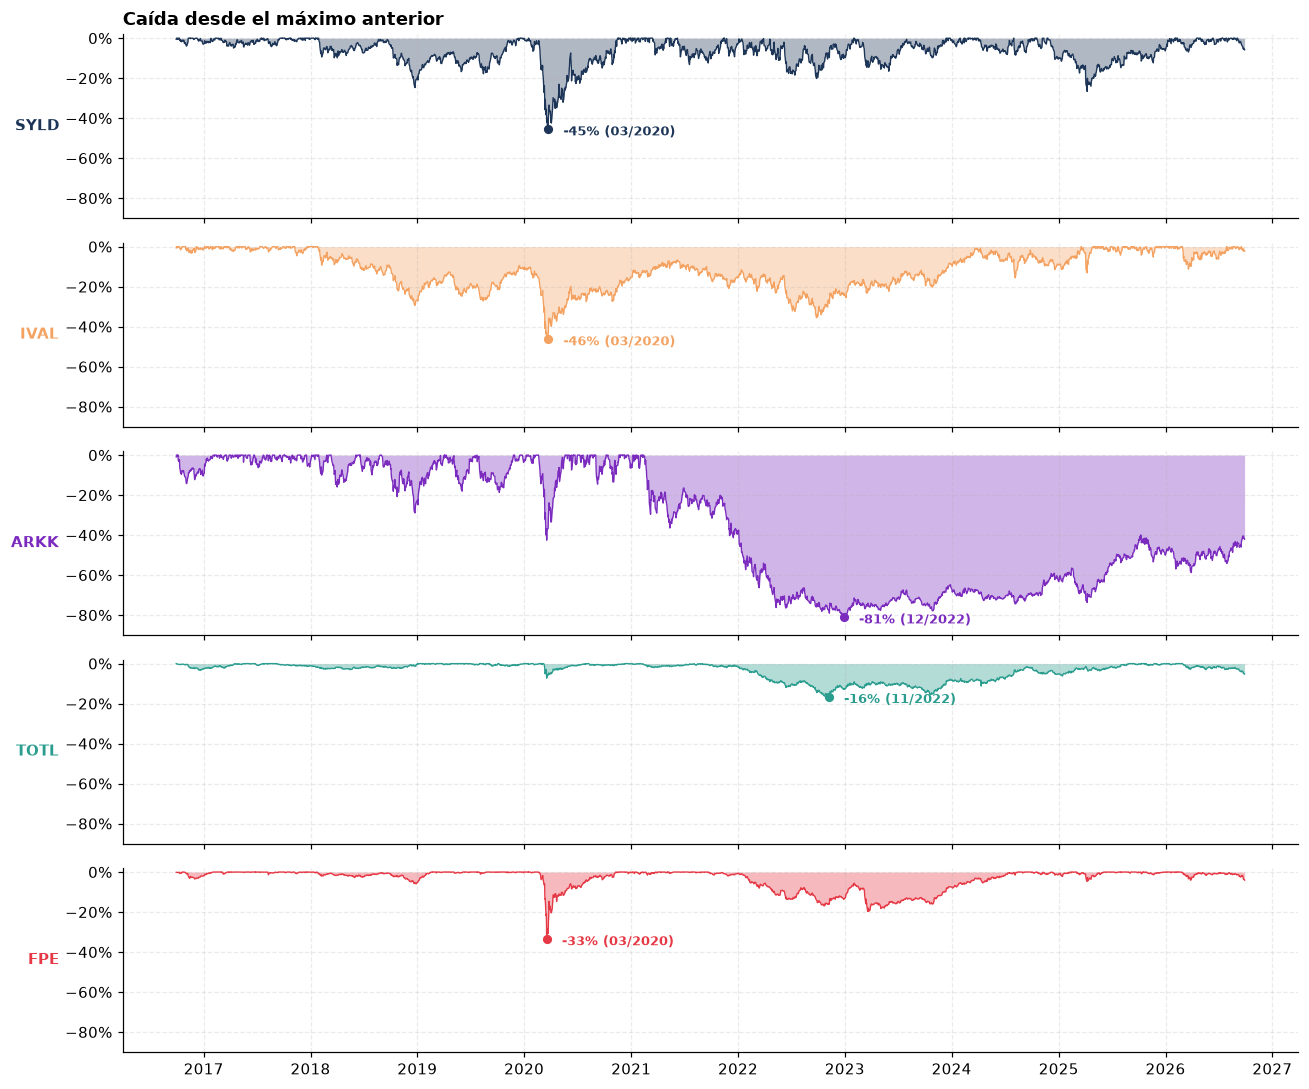

In [5]:
drawdown = risk.drawdown_series(returns)

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 10), sharex=True, sharey=True)
for ax, asset in zip(axes, TICKERS):
    series = -drawdown[asset]
    ax.fill_between(series.index, series, 0, color=COLORS[asset], alpha=0.35, lw=0)
    ax.plot(series.index, series, color=COLORS[asset], lw=0.9)
    bottom = series.idxmin()
    ax.scatter(bottom, series.min(), color=COLORS[asset], s=25, zorder=3)
    ax.annotate(f"{series.min():.0%} ({bottom:%m/%Y})", xy=(bottom, series.min()),
                xytext=(10, -2), textcoords="offset points", fontsize=8.5, va="center",
                color=COLORS[asset], fontweight="bold")
    ax.set_ylabel(asset, rotation=0, ha="right", va="center", color=COLORS[asset], fontweight="bold")
    ax.yaxis.set_major_formatter(PCT)
    ax.set_ylim(-0.9, 0.02)
axes[0].set_title("Caída desde el máximo anterior")
fig.tight_layout()
plt.show()

ARKK cayó un **81 %** entre 2021 y 2022 y todavía no se ha recuperado. SYLD, IVAL y FPE tocaron fondo en la
COVID, pero SYLD y FPE se recuperaron en unos ocho meses, mientras que IVAL estuvo siete años bajo el agua.
TOTL es el más estable: su peor caída es del 16 %, en 2022.

### Volatilidad móvil

Usamos dos ventanas: 63 sesiones (un trimestre) y 252 (un año). La línea discontinua es la volatilidad de toda
la muestra. Cada panel tiene su propia escala, porque la renta fija se mueve mucho menos.

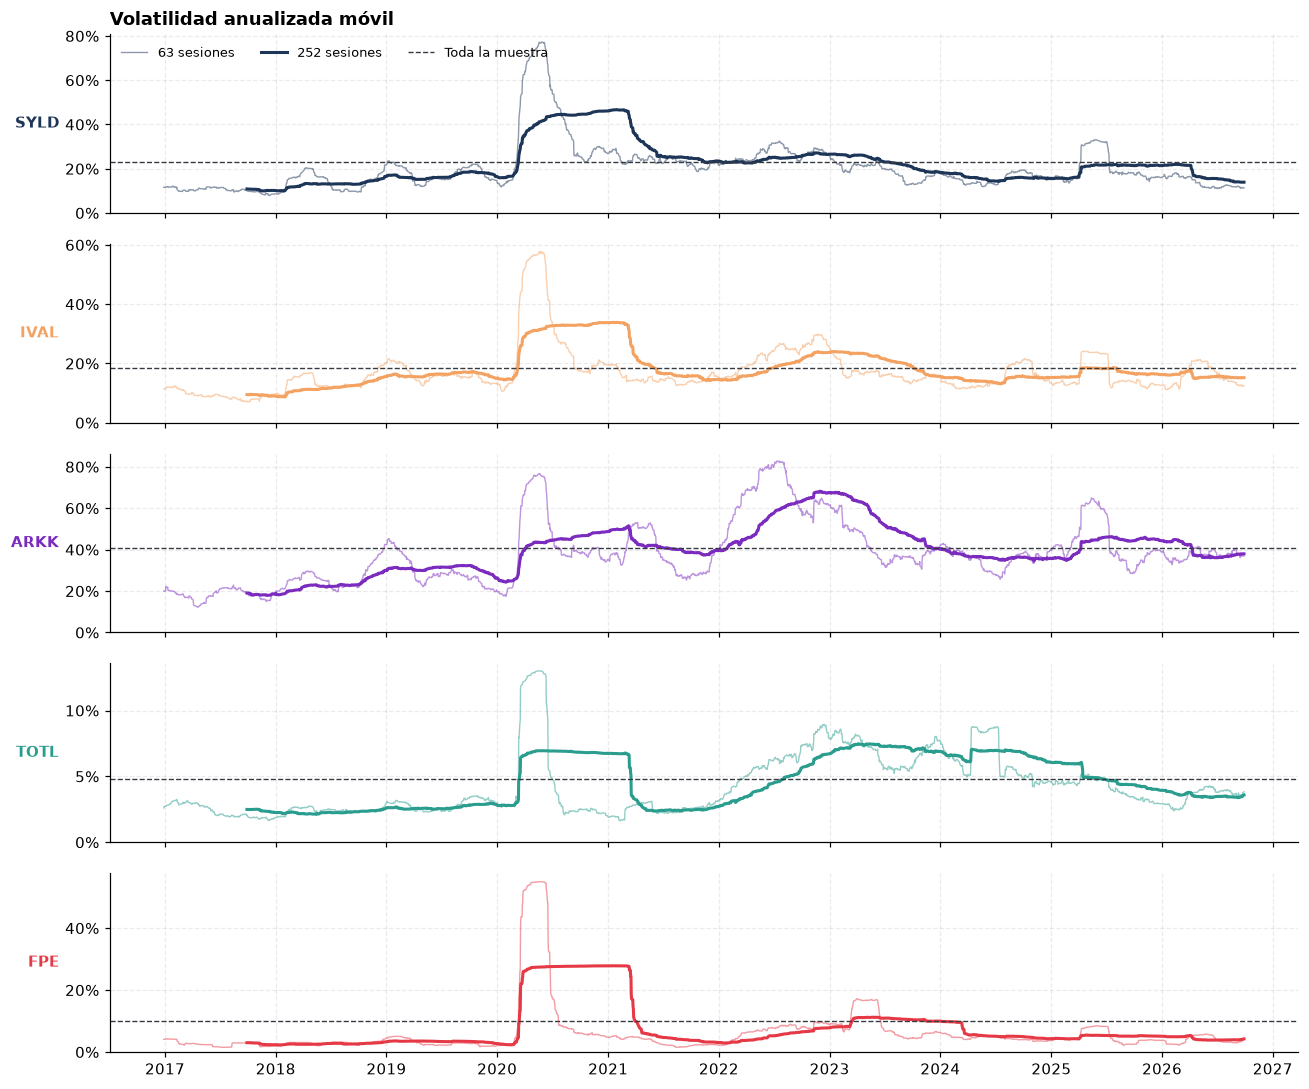

In [6]:
vol_quarter = risk.rolling_volatility(returns, window=63, periods_per_year=PPY)
vol_year = risk.rolling_volatility(returns, window=252, periods_per_year=PPY)

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 10), sharex=True)
for ax, asset in zip(axes, TICKERS):
    ax.plot(vol_quarter.index, vol_quarter[asset], color=COLORS[asset], lw=0.9, alpha=0.5,
            label="63 sesiones")
    ax.plot(vol_year.index, vol_year[asset], color=COLORS[asset], lw=2, label="252 sesiones")
    ax.axhline(summary.loc[asset, "Volatilidad anualizada"], color="#343a40", lw=0.9, ls="--",
               label="Toda la muestra")
    ax.set_ylabel(asset, rotation=0, ha="right", va="center", color=COLORS[asset], fontweight="bold")
    ax.yaxis.set_major_formatter(PCT)
    ax.set_ylim(bottom=0)
axes[0].set_title("Volatilidad anualizada móvil")
axes[0].legend(loc="upper left", ncol=3, fontsize=8.5)
fig.tight_layout()
plt.show()

La volatilidad **no es constante**: en los cinco fondos se dispara en la COVID (2020), y en ARKK y TOTL
también en 2022, con la subida de tipos. El caso más extremo es FPE, que pasa de moverse como un bono a
moverse como una acción durante la COVID.

### Histograma de retornos con VaR y CVaR al 95 %

La curva gris es la normal con la misma media y volatilidad. La línea naranja marca el VaR histórico al 95 % y
la roja, el CVaR histórico al 95 %.

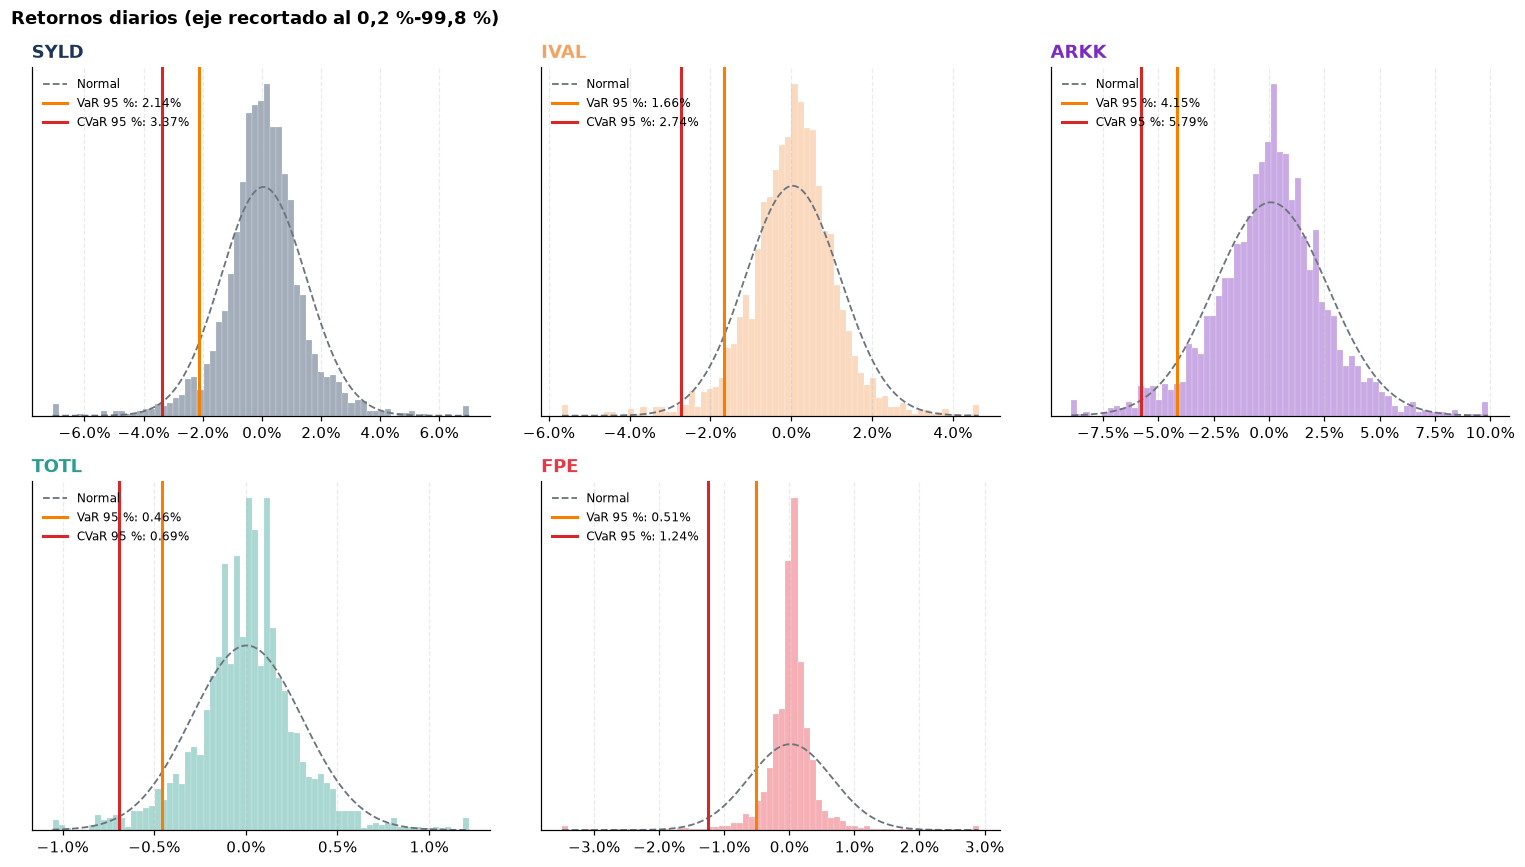

In [7]:
var_hist = risk.var_historical(returns, CONFIDENCE)
cvar_hist = risk.cvar_historical(returns, CONFIDENCE)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, asset in zip(axes, TICKERS):
    series = returns[asset]
    low, high = series.quantile([0.002, 0.998])
    ax.hist(series.clip(low, high), bins=np.linspace(low, high, 70), density=True,
            color=COLORS[asset], alpha=0.4, edgecolor="white", lw=0.3)
    grid = np.linspace(low, high, 400)
    normal = NormalDist(series.mean(), series.std())
    ax.plot(grid, [normal.pdf(x) for x in grid], color="#6c757d", lw=1.2, ls="--", label="Normal")
    ax.axvline(-var_hist[asset], color="#f77f00", lw=2, label=f"VaR 95 %: {var_hist[asset]:.2%}")
    ax.axvline(-cvar_hist[asset], color="#d62828", lw=2, label=f"CVaR 95 %: {cvar_hist[asset]:.2%}")
    ax.set_title(asset, color=COLORS[asset])
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
    ax.set_yticks([])
    ax.legend(fontsize=8, loc="upper left")
axes[-1].axis("off")
fig.suptitle("Retornos diarios (eje recortado al 0,2 %-99,8 %)", fontweight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

Los cinco tienen más días tranquilos y más días extremos que una normal. El CVaR diario va del 0,7 % (TOTL) al
5,8 % (ARKK): con un millón de euros, un día malo cuesta de media entre 7.000 € y 58.000 €.

## 4. Preguntas

### 1. Ahora mismo os dan 1 M€. ¿Os convence alguna cartera? ¿Cuál y por qué?

**Sí: SYLD (Cambria Shareholder Yield).** Es el que mejor combina rentabilidad y riesgo en la tabla:

- Es el **primero por Sharpe (0,63), Sortino (0,90) y Calmar (0,28)**.
- Su peor caída (45 %, en la COVID) se **recuperó en 166 sesiones, unos ocho meses**. ARKK sigue sin
  recuperarse, e IVAL necesitó siete años.
- Tiene un CAGR del 12,6 %, algo menos que ARKK (15,9 %), pero con la mitad de volatilidad (23 % frente a 41 %)
  y casi la mitad de probabilidad de susto (22 % frente a 43 %).

ARKK no nos convence: rentó más, pero con una caída del 81 % de la que aún no ha salido. Los fondos de renta
fija tampoco, como inversión única: TOTL creció solo un 1,1 % anual y FPE, un 4,3 %.

Aun así, no pondríamos el millón entero en SYLD: una caída del 45 % es mucho para un solo fondo, y los cinco
cotizan en dólares, lo que añade riesgo de divisa para un inversor en euros.

### 2. ¿Qué activo tiene el peor perfil de cola y por qué no se aprecia mirando solo la volatilidad?

In [8]:
daily_vol = returns.std()
pd.DataFrame({
    "Volatilidad anual": summary["Volatilidad anualizada"],
    "VaR 95 %": var_hist,
    "Peor día": returns.min(),
    "Peor día (en σ diarias)": returns.min() / daily_vol,
    "Asimetría": summary["Asimetría"],
    "Curtosis": summary["Curtosis (exceso)"],
}).style.format({
    "Volatilidad anual": "{:.1%}", "VaR 95 %": "{:.2%}", "Peor día": "{:.1%}",
    "Peor día (en σ diarias)": "{:.1f}", "Asimetría": "{:.2f}", "Curtosis": "{:.1f}",
})

,Volatilidad anual,VaR 95 %,Peor día,Peor día (en σ diarias),Asimetría,Curtosis
SYLD,22.9%,2.14%,-11.0%,-7.6,-0.24,9.9
IVAL,18.5%,1.66%,-11.3%,-9.6,-0.62,11.4
ARKK,40.6%,4.15%,-15.6%,-6.1,0.01,2.9
TOTL,4.8%,0.46%,-3.6%,-12.0,-0.95,19.8
FPE,10.2%,0.51%,-15.6%,-24.4,-5.62,207.5


**FPE (preferentes e híbridos).** Mirando la volatilidad parece uno de los fondos más seguros: un **10 %**
anual, la segunda más baja, y un VaR diario de solo el 0,5 %. Pero:

- Su **peor día fue −15,6 %**, el mismo que el de ARKK, que tiene cuatro veces más volatilidad. Para FPE esa
  caída equivale a **24 desviaciones típicas diarias**; para ARKK, a 6. Con una normal, algo así sería
  prácticamente imposible.
- Tiene una **curtosis de 207** y una **asimetría de −5,6**, con diferencia las más extremas: sus días extremos
  son caídas.
- Llegó a perder un **33 %**, más que algunos fondos de acciones en una crisis normal.

La volatilidad no lo refleja porque es una **media de todos los días**, y casi todos los días FPE apenas se
mueve. El riesgo está concentrado en unos pocos días de crisis de liquidez (marzo de 2020), que casi no pesan
en la media. Además, la volatilidad trata igual subidas y bajadas, así que no ve que las colas de FPE van
hacia abajo.

En pérdida absoluta, el fondo con más riesgo es ARKK (CVaR del 5,8 % y caída del 81 %), pero en su caso la
volatilidad sí avisa: es el más volátil y el más parecido a una normal (curtosis 2,9).

### 3. ¿Coincide el ranking por Sharpe con el ranking por Calmar?

In [9]:
ranking = pd.DataFrame({
    "Sharpe": summary["Sharpe"],
    "Puesto Sharpe": summary["Sharpe"].rank(ascending=False).astype(int),
    "Calmar": summary["Calmar"],
    "Puesto Calmar": summary["Calmar"].rank(ascending=False).astype(int),
    "Máx. drawdown": summary["Máx. drawdown"],
}).sort_values("Puesto Sharpe")
ranking.style.format({"Sharpe": "{:.2f}", "Calmar": "{:.2f}", "Máx. drawdown": "{:.1%}"})

,Sharpe,Puesto Sharpe,Calmar,Puesto Calmar,Máx. drawdown
SYLD,0.63,1,0.28,1,45.4%
ARKK,0.57,2,0.20,2,80.9%
IVAL,0.49,3,0.17,3,46.1%
FPE,0.46,4,0.13,4,33.3%
TOTL,0.25,5,0.07,5,16.5%


**Sí, coincide**: los dos ordenan a los cinco fondos igual (SYLD, ARKK, IVAL, FPE, TOTL). Pasa porque, en
esta muestra, los fondos más volátiles son también los que más cayeron.

Lo que sí cambia son las **distancias**. Por Sharpe, ARKK está muy cerca de SYLD (0,57 frente a 0,63), porque
el Sharpe solo penaliza la volatilidad. Por Calmar, la distancia se abre (0,20 frente a 0,28), porque el
Calmar divide entre la peor caída y la de ARKK fue del 81 %. Es decir, los rankings coinciden, pero el
Calmar ve mucho mejor el coste de haber estado en ARKK en 2021-2022.

### 4. ¿Cómo se comporta el VaR paramétrico en dos periodos diferentes?

Comparamos un periodo tranquilo (**2016-2019**) con uno de estrés (**2020-2022**: COVID y subida de tipos).

In [10]:
calm, stress = returns.loc["2016":"2019"], returns.loc["2020":"2022"]

var_periods = pd.DataFrame({
    "VaR gaussiano 2016-19": risk.var_parametric(calm, CONFIDENCE),
    "VaR gaussiano 2020-22": risk.var_parametric(stress, CONFIDENCE),
    "VaR histórico 2016-19": risk.var_historical(calm, CONFIDENCE),
    "VaR histórico 2020-22": risk.var_historical(stress, CONFIDENCE),
})
# Días de 2020-22 en que la pérdida superó el VaR gaussiano de 2016-19 (debería ser un 5 %).
var_periods["Excesos en 2020-22 con el VaR de 2016-19"] = (
    stress.lt(-var_periods["VaR gaussiano 2016-19"], axis=1).mean()
)
var_periods.style.format("{:.2%}")

,VaR gaussiano 2016-19,VaR gaussiano 2020-22,VaR histórico 2016-19,VaR histórico 2020-22,Excesos en 2020-22 con el VaR de 2016-19
SYLD,1.46%,3.40%,1.54%,2.95%,18.78%
IVAL,1.36%,2.63%,1.39%,2.40%,13.62%
ARKK,2.48%,5.54%,2.62%,5.71%,20.37%
TOTL,0.26%,0.61%,0.26%,0.51%,15.74%
FPE,0.29%,1.74%,0.30%,0.72%,16.80%


**Cambia muchísimo.** El VaR gaussiano solo depende de la media y la volatilidad, así que cuando la
volatilidad sube, él también. Del periodo tranquilo al de estrés, se multiplica por más de dos en SYLD, ARKK
y TOTL, y **por seis en FPE**.

Eso significa que un VaR calculado en época tranquila **no protege** cuando llega la crisis. Con el VaR de
2016-2019, las pérdidas de 2020-2022 lo superaron **entre el 14 % y el 20 % de los días**, cuando deberían
haberlo hecho el 5 %.

Además, con colas extremas el modelo se equivoca en los dos sentidos. En 2020-2022, el VaR gaussiano de FPE es
del 1,7 % y el histórico, del 0,7 %: un solo mes de crisis infla tanto la volatilidad que el modelo exagera la
pérdida de un día malo normal. Y a la vez se queda muy corto en el peor día (−15,6 %).

### 5. ¿Qué nos dice la métrica que habéis creado?

La **probabilidad de susto** responde a: *"si entro un día cualquiera, ¿qué probabilidad hay de que en el año
siguiente llegue a perder más de lo que soporto?"*. En la tabla resumen usa un límite del 20 %. Como depende de
cuánto aguante cada cliente, la calculamos también con otros límites.

In [11]:
worst_ahead = risk.worst_loss_ahead(returns)  # peor pérdida del año siguiente para cada fecha de entrada
LIMITS = [0.05, 0.10, 0.20, 0.30, 0.40]

scare = pd.DataFrame({f"Perder más de un {limit:.0%}": (worst_ahead > limit).mean() for limit in LIMITS})
scare.style.format("{:.1%}").background_gradient(cmap="Reds", axis=None)

,Perder más de un 5%,Perder más de un 10%,Perder más de un 20%,Perder más de un 30%,Perder más de un 40%
SYLD,63.4%,49.1%,22.2%,10.9%,3.8%
IVAL,66.0%,46.7%,28.8%,9.2%,0.1%
ARKK,76.7%,68.4%,42.8%,23.1%,15.2%
TOTL,23.4%,9.2%,0.0%,0.0%,0.0%
FPE,34.7%,24.8%,11.1%,4.4%,0.0%


- **Traduce el riesgo al lenguaje del cliente.** "Con SYLD, entrando cualquier día, hubo un 22 % de
  probabilidad de llegar a perder más de un 20 % en el año siguiente" se entiende mejor que "volatilidad del
  23 %".
- **Ordena distinto que el Sharpe.** ARKK es el 2.º por Sharpe, pero el que más asusta con cualquier límite:
  en el 43 % de las entradas llegó a perder más de un 20 %.
- **Depende del perfil.** Con un límite del 20 %, TOTL nunca asusta (0 %), pero ese límite no tiene sentido
  para quien compra un fondo de bonos. Con un límite del 5 %, TOTL asusta en el 23 % de las entradas y FPE, en
  el 35 %.
- **El orden cambia con el límite.** Con un 20 %, IVAL asusta más que SYLD (29 % frente a 22 %). Con un 40 %,
  ocurre lo contrario: IVAL tiene caídas moderadas frecuentes y SYLD, pocas pero más profundas. Un solo número
  como la volatilidad o el drawdown no recoge esta diferencia.

Su limitación es que se basa en el pasado y no dice *cuánto* se pierde más allá del límite, así que
complementa al CVaR y al drawdown, no los sustituye.